In [1]:
!python --version

Python 3.13.7


In [1]:
from math import gamma

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cbook
from PIL import Image
from scipy.stats import multivariate_normal, norm
import networkx as nx
import torch
from torch.nn import Conv2d
from torch.nn.utils import parameters_to_vector

In [4]:
with open(r"../root.jpeg", mode="rb") as fp:
    root = np.array(Image.open(fp), dtype=np.uint8)

In [24]:
image_h, image_w, _ = np.array(root.shape) // 300

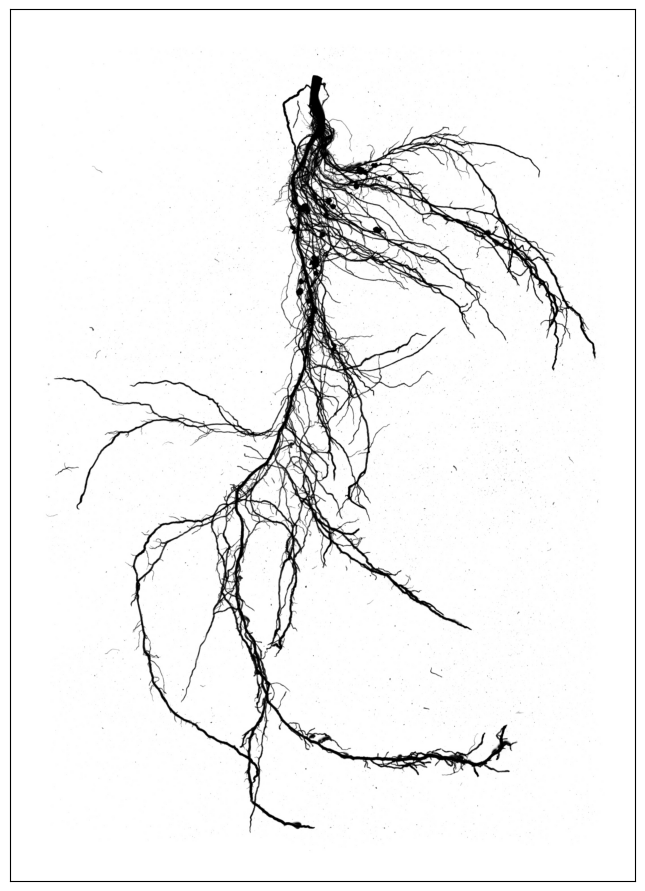

In [25]:
fig, axes = plt.subplots()
fig.set_size_inches(image_w, image_h)
axes.imshow(root)
plt.tight_layout()
axes.set_xticks([])
axes.set_yticks([])
plt.show()

In [34]:
root_tensor = torch.FloatTensor(np.array(np.unstack(root, axis=2)) / 255.0)
root_tensor.shape

torch.Size([3, 3078, 2207])

In [39]:
with torch.no_grad():
    convolutions = Conv2d(in_channels=3, out_channels=9, kernel_size=(4, 4), stride=(1, 1))(root_tensor)

In [41]:
convolutions.shape

torch.Size([9, 3075, 2204])

In [10]:
with open(file=r"\\ad.uws.edu.au\dfshare\HomesBNK$\90963425\Downloads\sam_vit_h_4b8939.pth", mode="rb") as fp:
    params_sam = torch.load(f=fp, map_location="cpu", weights_only=False)

In [14]:
sam_n_params = np.array(list(map(torch.numel, params_sam.values())))

In [17]:
sam_n_params.sum() / 1e6

np.float64(641.090864)

In [20]:
params_sam.get("model_state", 0)

0

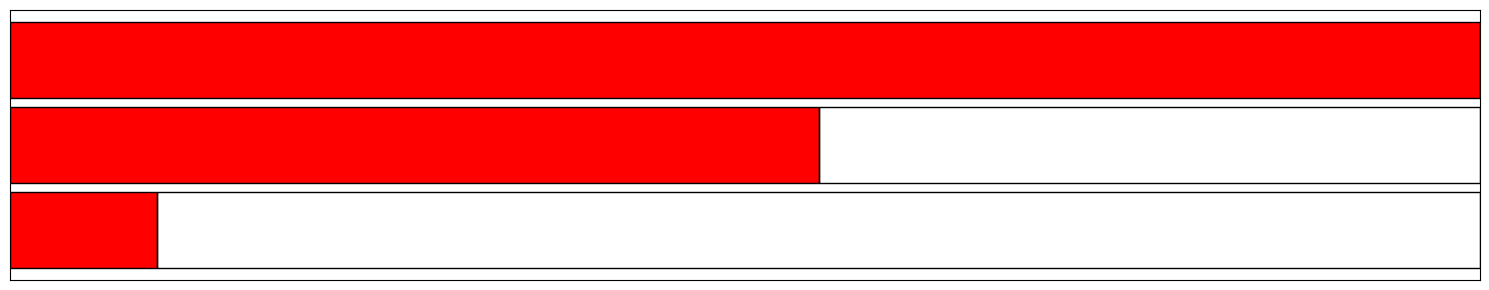

In [2]:
start = np.linspace(10, 100, 3)
fig, axes = plt.subplots()
fig.set_size_inches(15, 3)
axes.barh(y=range(3), width=start, height=0.90, color="red", edgecolor="black")
axes.barh(y=range(3), width=100-start, left=start, height=0.90, color="none", edgecolor="black")
axes.set_xticks([])
axes.set_yticks([])
plt.tight_layout()
plt.show()
# plt.savefig(r"../plots/indic.png", format="png", dpi=300)

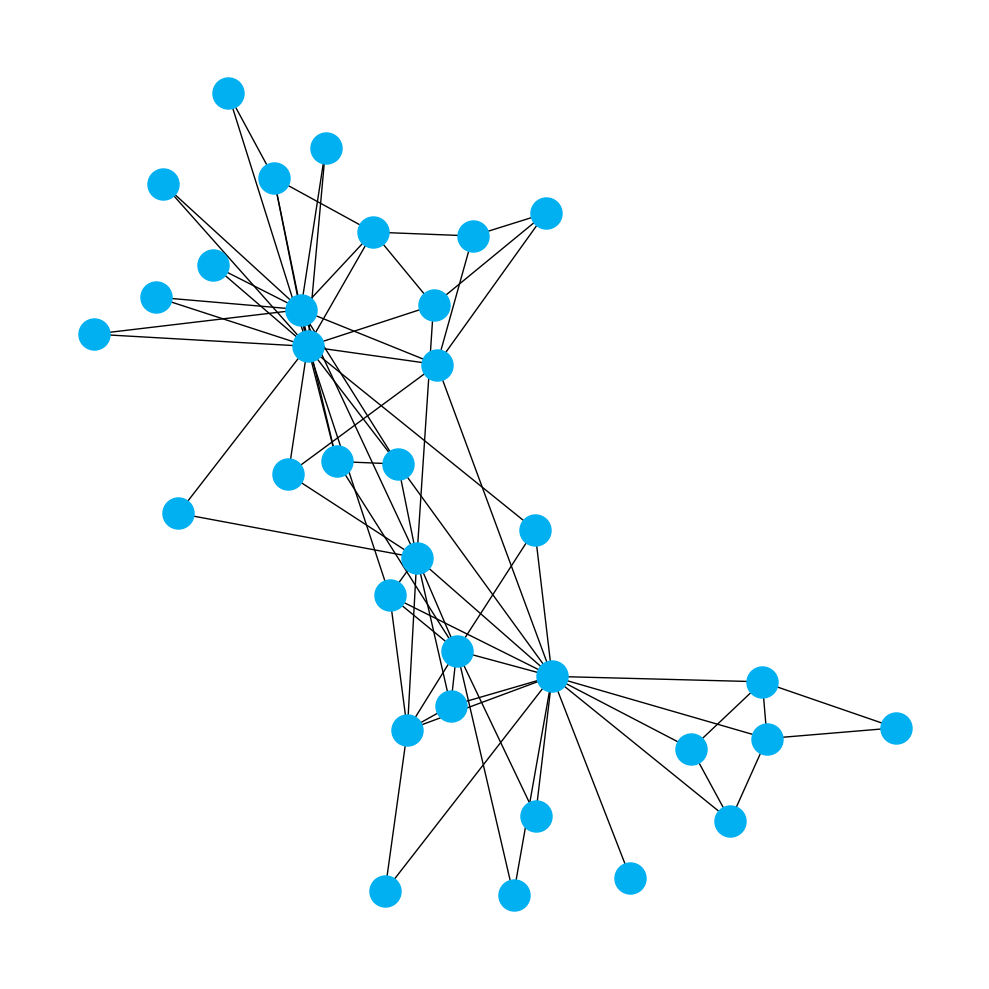

In [2]:
karate = nx.karate_club_graph()
fig, axes = plt.subplots()
fig.set_size_inches(10, 10)

for c in ("#C04F15", "#FFC000", "#00B050", "#00B0F0"):
    axes.clear()
    nx.draw(karate, ax=axes, edge_color="black", node_color=c, node_size=500, pos=nx.spring_layout(karate))
    plt.tight_layout()
    plt.savefig(fname=f"../plots/karate_{c}.png", format="png", dpi=400, transparent=True)
    # plt.show()

In [2]:
# https://networkx.org/documentation/stable/auto_examples/graphviz_layout/plot_lanl_routes.html#sphx-glr-auto-examples-graphviz-layout-plot-lanl-routes-py

def lanl_graph(path: str) -> nx.Graph:
    """Return the lanl internet view graph from lanl.edges"""
    try:
        with open(file=path, mode="rt") as fh:
            G = nx.Graph()
            time = {}
            time[0] = 0  # assign 0 to center node
            for line in fh.readlines():
                (head, tail, rtt) = line.split()
                G.add_edge(int(head), int(tail))
                time[int(head)] = float(rtt)
        
            # get largest component and assign ping times to G0time dictionary
            Gcc = sorted(nx.connected_components(G), key=len, reverse=True)[0]
            G0 = G.subgraph(Gcc)
            G0.rtt = {}
            for n in G0:
                G0.rtt[n] = time[n]
        
            return G0
    except OSError as os_excpt:
        raise RuntimeError(f"Specified edgelist file {path} not foound in disk!") from os_excpt

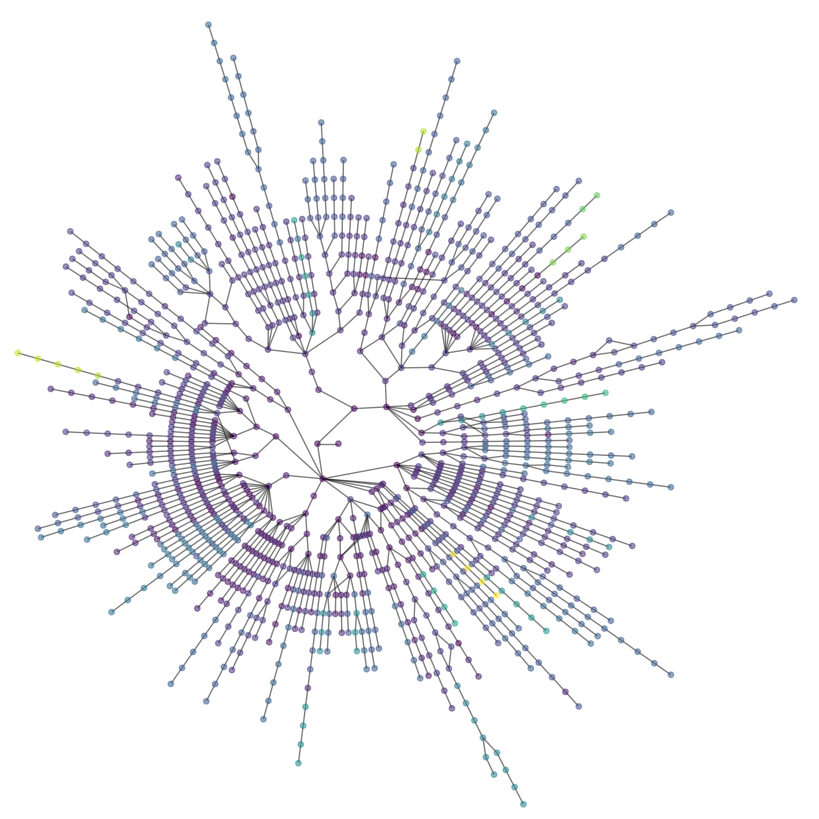

In [10]:
G = lanl_graph(r"../data/chapter3/lanl_routes.edgelist")

plt.figure(figsize=(8, 8))
# use graphviz to find radial layout
pos = nx.nx_agraph.graphviz_layout(G, prog="twopi", root=0)
# draw nodes, coloring by rtt ping time
options = {"with_labels": False, "alpha": 0.5, "node_size": 15}
nx.draw(G, pos, node_color=[G.rtt[v] for v in G], **options)
# adjust the plot limits
xmax = 1.02 * max(xx for xx, yy in pos.values())
ymax = 1.02 * max(yy for xx, yy in pos.values())
plt.xlim(0, xmax)
plt.ylim(0, ymax)
plt.show()

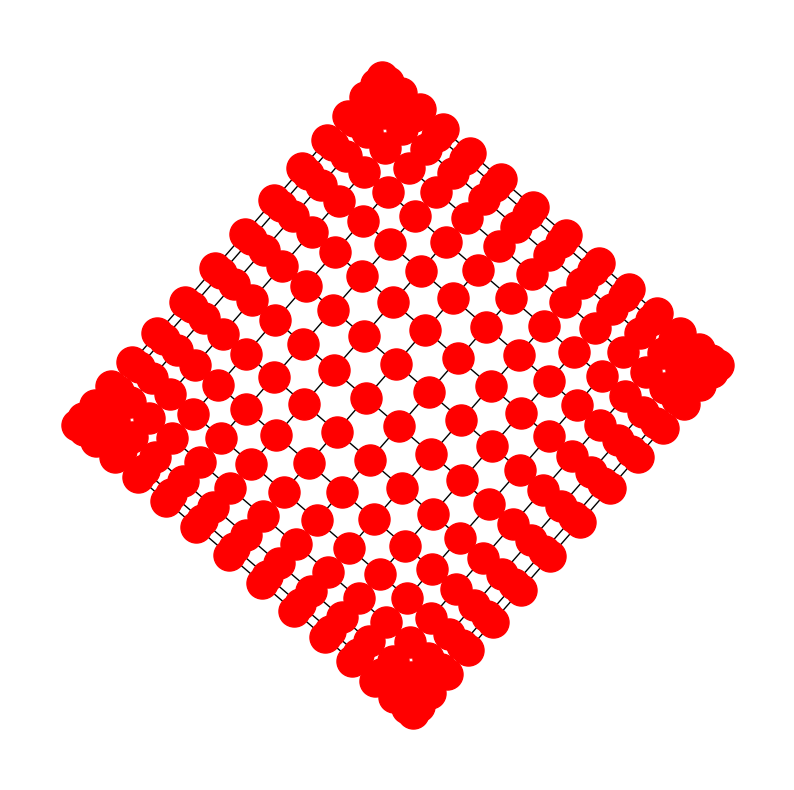

In [31]:
fig, axes = plt.subplots()
fig.set_size_inches(10, 10)
graph = nx.grid_2d_graph(16, 16)
nx.draw_spectral(graph, edge_color="black", node_color="red", node_size=500)

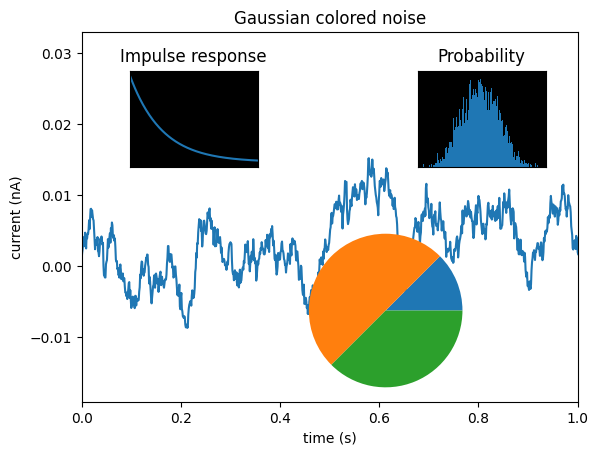

In [61]:
np.random.seed(19680801)  # Fixing random state for reproducibility.

# create some data to use for the plot
dt = 0.001
t = np.arange(0.0, 10.0, dt)
r = np.exp(-t[:1000] / 0.05)  # impulse response
x = np.random.randn(len(t))
s = np.convolve(x, r)[:len(x)] * dt  # colored noise

fig, main_ax = plt.subplots()
main_ax.plot(t, s)
main_ax.set_xlim(0, 1)
main_ax.set_ylim(1.1 * np.min(s), 2 * np.max(s))
main_ax.set_xlabel('time (s)')
main_ax.set_ylabel('current (nA)')
main_ax.set_title('Gaussian colored noise')

# this is an inset Axes over the main Axes
right_inset_ax = fig.add_axes([.65, .6, .2, .2], facecolor='k')
right_inset_ax.hist(s, 400, density=True)
right_inset_ax.set(title='Probability', xticks=[], yticks=[])

# this is another inset Axes over the main Axes
left_inset_ax = fig.add_axes([.2, .6, .2, .2], facecolor='k')
left_inset_ax.plot(t[:len(r)], r)
left_inset_ax.set(title='Impulse response', xlim=(0, .2), xticks=[], yticks=[])

ax = fig.add_axes([0.4, 0.1, .4, .4]) # tuple (left, bottom, width, height)
ax.pie(x=(12.5, 50, 37.5), startangle=0)

plt.show()

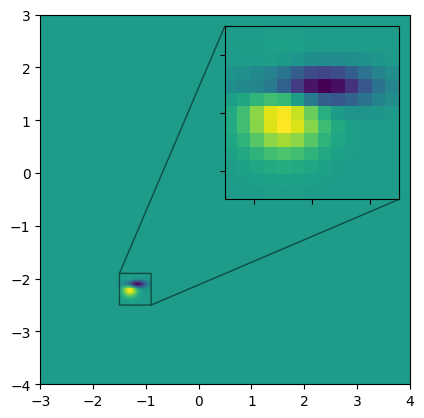

In [20]:
fig, ax = plt.subplots()

# make data
Z = cbook.get_sample_data("axes_grid/bivariate_normal.npy")  # 15x15 array
Z2 = np.zeros((150, 150))
ny, nx = Z.shape
Z2[30:30+ny, 30:30+nx] = Z
extent = (-3, 4, -4, 3)

ax.imshow(Z2, extent=extent, origin="lower")

# inset Axes....
x1, x2, y1, y2 = -1.5, -0.9, -2.5, -1.9  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.5, 0.47, 0.47],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins.imshow(Z2, extent=extent, origin="lower")

ax.indicate_inset_zoom(axins, edgecolor="black")

plt.show()

In [13]:
image = np.array(Image.open(r"../leaf_area.png"))
# image.shape
# image[:, :int(image.shape[1]/2.0)] =  image[:, :int(image.shape[1]/2.0)] * 0.45
# adjusting just the alpha channel did not help
image[:, :int(image.shape[1]/2.0)][:, :, :3] = image[:, :int(image.shape[1]/2.0)][:, :, :3] * .55

In [15]:
image.shape

(1313, 876, 4)

In [16]:
# the alpha channel
image[:, :int(image.shape[1]/2.0)][:, :, 3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1313, 438), dtype=uint8)

In [17]:
# just the RGB channels or CMYK???
image[:, :int(image.shape[1]/2.0)][:, :, :3]

array([[[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [ 89,  64,  73],
        [100,  79,  85],
        [132, 113, 118]],

       [[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [ 89,  64,  73],
        [ 83,  60,  66],
        [122, 103, 108]],

       [[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [ 91,  64,  73],
        [ 71,  46,  53],
        [103,  82,  88]],

       ...,

       [[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [140, 140, 140],
        [140, 140, 140],
        [140, 140, 140]],

       [[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [140, 140, 140],
        [140, 140, 140],
        [140, 140, 140]],

       [[140, 140, 140],
        [140, 140, 140],
        [140, 140, 140],
        ...,
        [140, 140, 140],
        [140, 140, 140],
        [140, 140, 140]]

In [18]:
image[:, :int(image.shape[1]/2.0)][:, :, 3].min(), image[:, :int(image.shape[1]/2.0)][:, :, 3].max()

(np.uint8(0), np.uint8(255))

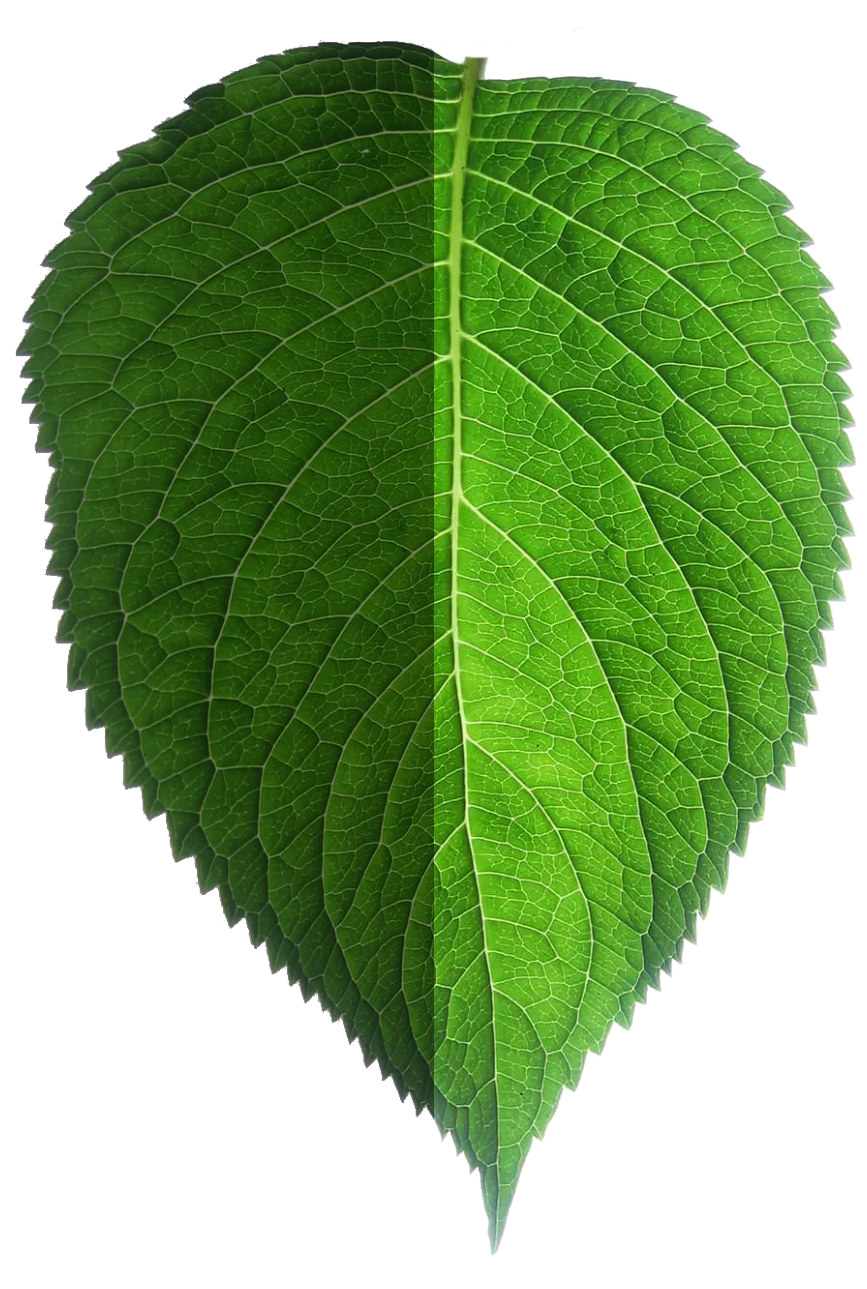

In [19]:
fig, axes = plt.subplots()
fig.set_size_inches(9, 13)
axes.set_axis_off()
axes.imshow(image)
plt.tight_layout()
plt.show()
# plt.savefig(r"../shade.png", dpi=400, transparent=True)

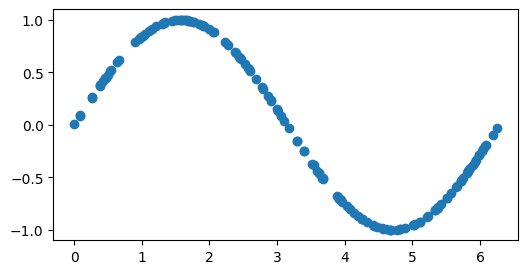

In [36]:
# create a ring of jittered dots

fig, axes = plt.subplots()
fig.set_size_inches(6, 3)

x = np.random.rand(150) * 2 * np.pi
y = np.sin(x) #+ np.random.rand(100)
axes.scatter(x, y)
plt.show()

In [11]:
x.max()

NameError: name 'x' is not defined

In [28]:
Z

array([[-0.08395308, -0.08984795, -0.091243  , ..., -0.091243  ,
        -0.08984795, -0.08395308],
       [-0.08984795, -0.09120042, -0.08769114, ..., -0.08769114,
        -0.09120042, -0.08984795],
       [-0.091243  , -0.08769114, -0.07913803, ..., -0.07913803,
        -0.08769114, -0.091243  ],
       ...,
       [-0.091243  , -0.08769114, -0.07913803, ..., -0.07913803,
        -0.08769114, -0.091243  ],
       [-0.08984795, -0.09120042, -0.08769114, ..., -0.08769114,
        -0.09120042, -0.08984795],
       [-0.08395308, -0.08984795, -0.091243  , ..., -0.091243  ,
        -0.08984795, -0.08395308]], shape=(50, 50))

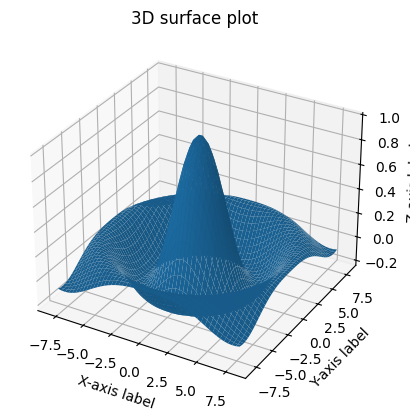

In [38]:
# Sample data
X, Y = np.meshgrid(np.linspace(-8, 8), 
                   np.linspace(-8, 8))
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R) / R

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

# 3D surface plot
ax.plot_surface(X, Y, Z)

# Axis labels
ax.set_xlabel('X-axis label')
ax.set_ylabel('Y-axis label')
ax.set_zlabel('Z-axis label')

# Title
plt.title("3D surface plot")
plt.show()

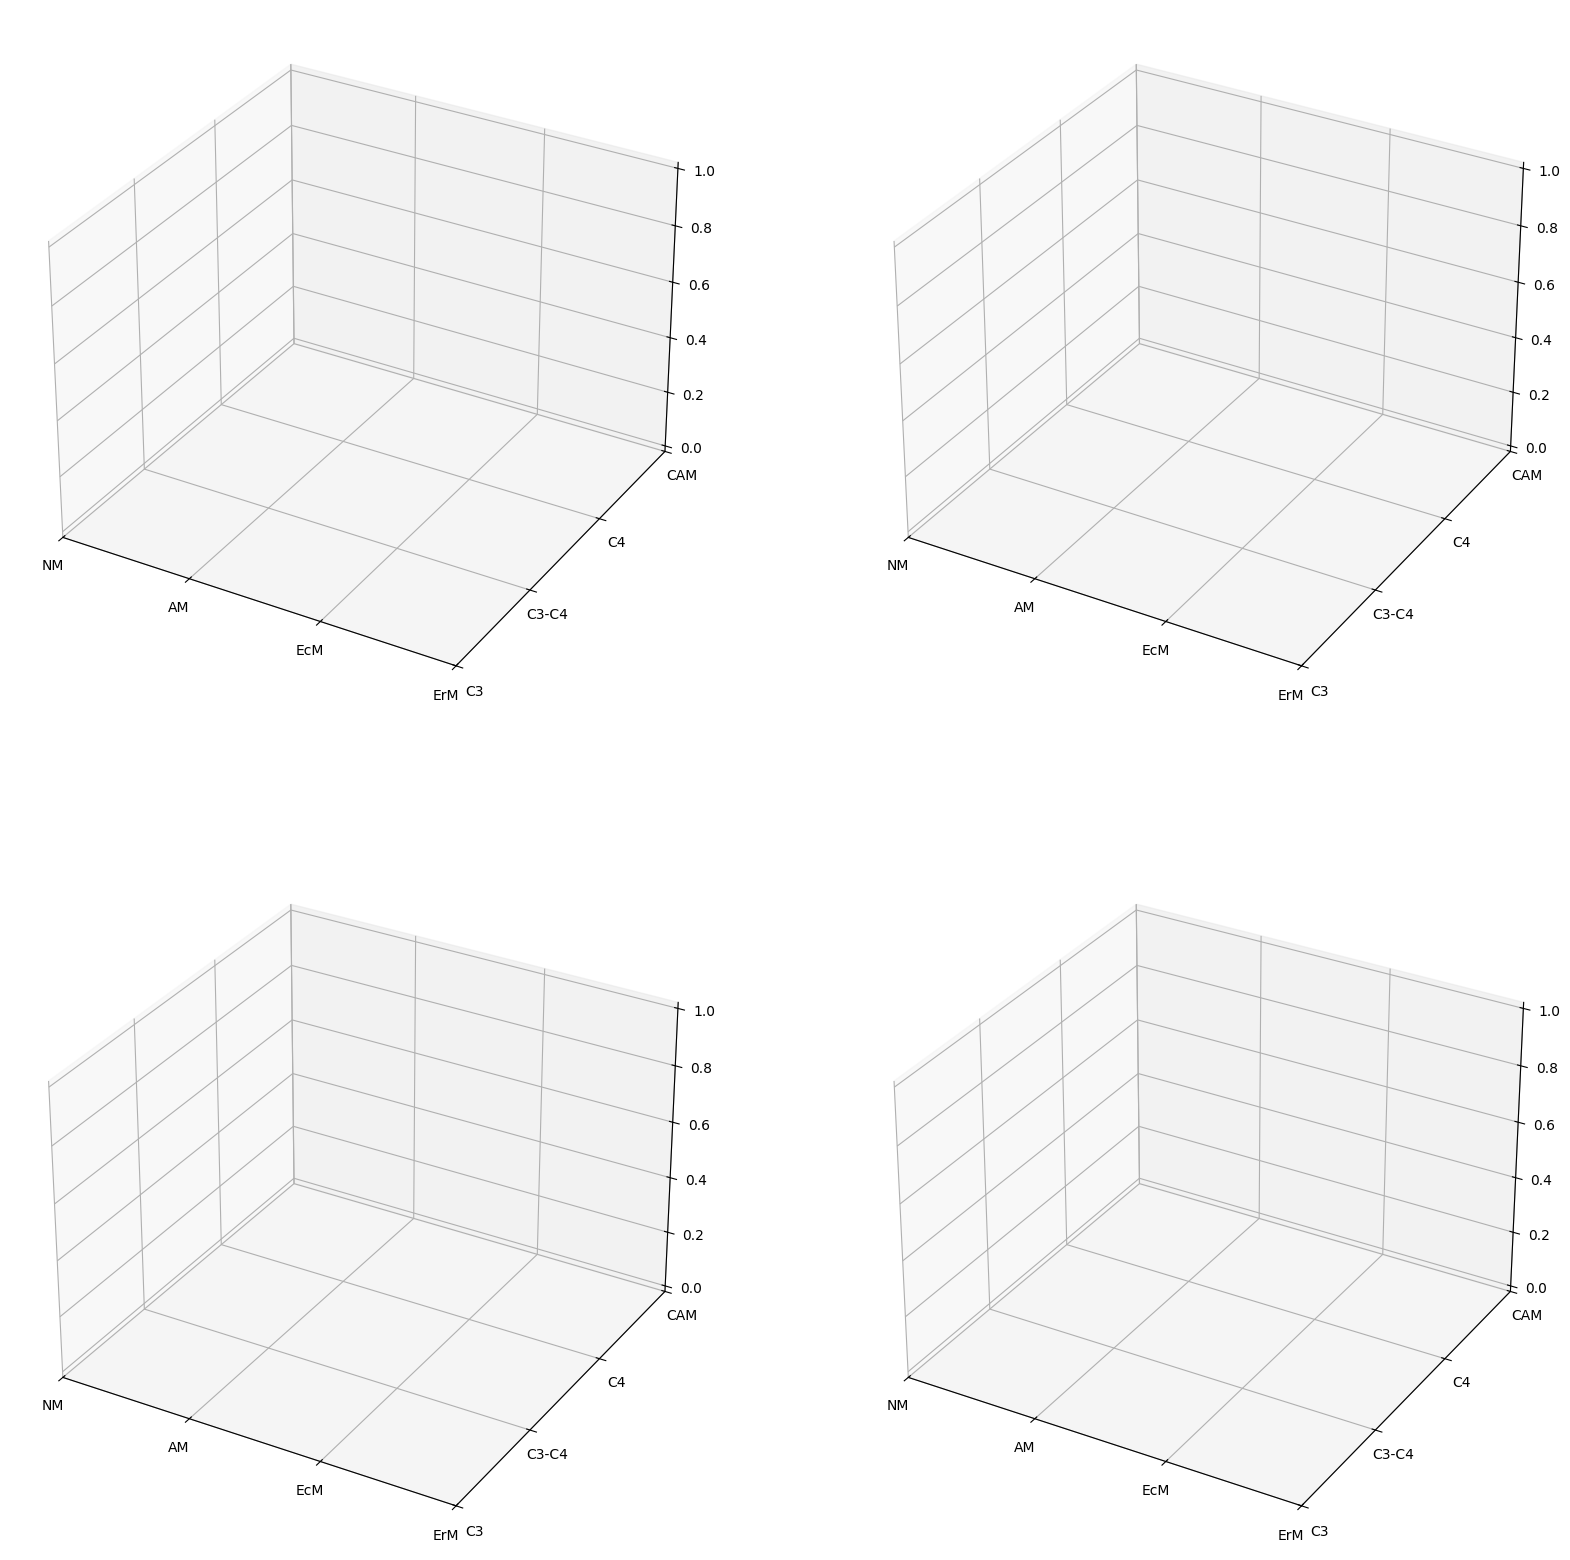

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=2, subplot_kw={"projection":"3d"}) # , sharex=True, sharey=True)
fig.set_size_inches(20, 20)

for ax in axes.flatten():
    ax.set_xticks(ticks=np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], num=4), labels=("NM", "AM", "EcM", "ErM"))
    ax.set_yticks(ticks=np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], num=4), labels=("C3", "C3-C4", "C4", "CAM"))

# plt.tight_layout()
plt.show()

In [15]:
# https://likegeeks.com/3d-probability-plots-python/

def distribution1(x, y):
    return multivariate_normal([0, 0], [[1, 0], [0, 1]]).pdf(np.dstack((x, y)))
    
def distribution2(x, y):
    return multivariate_normal([2, 2], [[1.5, 0.5], [0.5, 1.5]]).pdf(np.dstack((x, y)))
    
x = np.linspace(-4, 6, 100)
y = np.linspace(-4, 6, 100)
X, Y = np.meshgrid(x, y)
Z1 = distribution1(X, Y)
Z2 = distribution2(X, Y)

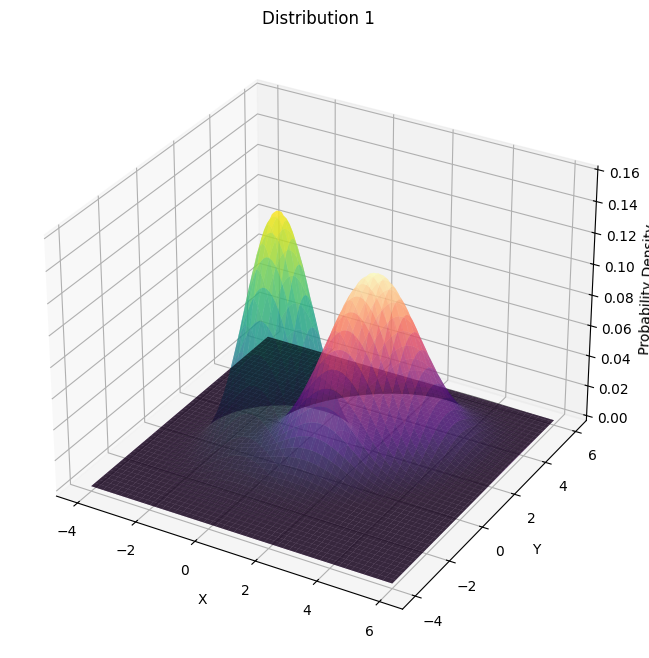

In [20]:
fig, axes = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_size_inches(8, 8)
axes.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.6)
axes.plot_surface(X, Y, Z2, cmap='magma', alpha=0.6)
axes.set_xlabel('X')
axes.set_ylabel('Y')
axes.set_zlabel('Probability Density')
axes.set_title('Distribution 1')

# plt.tight_layout()
plt.show()

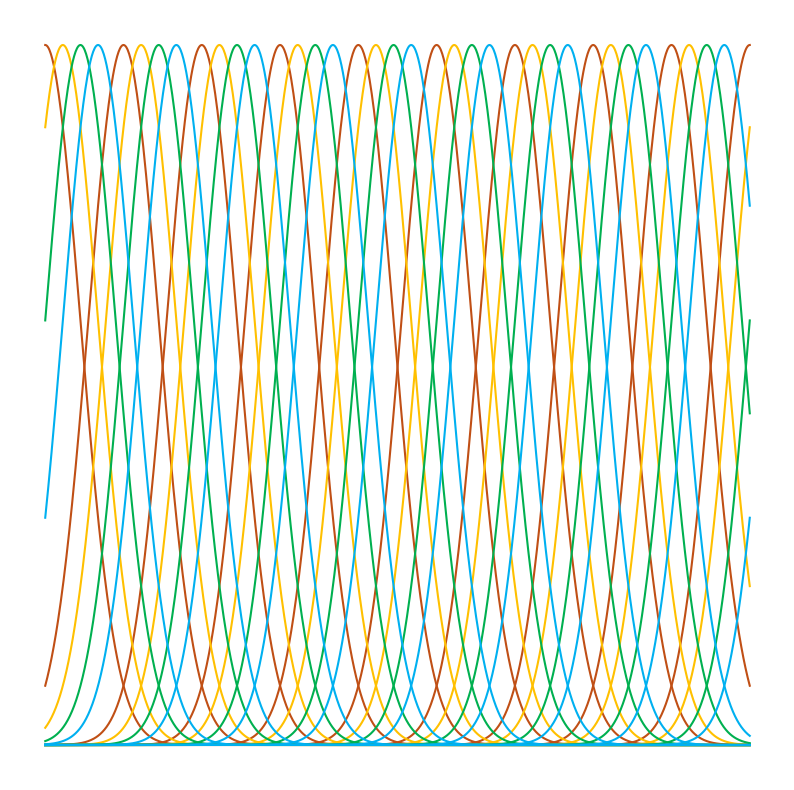

In [18]:
fig, axes = plt.subplots()
fig.set_size_inches(10, 10)
x = np.linspace(0, 1, 1000)
means = np.linspace(start=0, stop=1, num=10)

for col in ("#C04F15", "#FFC000", "#00B050", "#00B0F0"):
    for m in means:
        axes.plot(x, norm.pdf(x, loc=m, scale=0.05), color=col)
    means += 0.025
axes.set_axis_off()
# plt.show()
plt.savefig(fname=r"../plots/fitness.png", format=r"png", transparent=True, dpi=600)

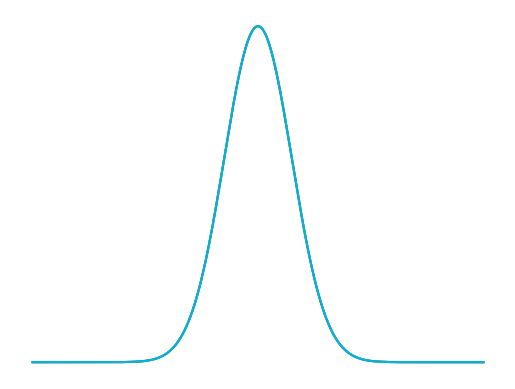

In [15]:
fig, axes = plt.subplots()
axes.set_axis_off()
x = np.linspace(0, 2, 1000)
y = norm.pdf(x, loc=1, scale=0.15)

for c in ("#C04F15", "#FFC000", "#00B050", "#00B0F0"):
    axes.plot(x, y, color=c)
    plt.savefig(f"../plots/bell_{c}.png", format=r"png", dpi=1000, transparent=True)

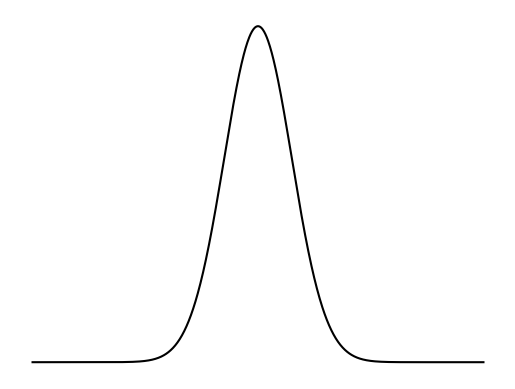

In [2]:
fig, axes = plt.subplots()
axes.set_axis_off()
x = np.linspace(0, 2, 1000)
y = norm.pdf(x, loc=1, scale=0.15)
axes.plot(x, y, color="black")
plt.savefig(f"../plots/bellcurve.png", format=r"png", dpi=1000, transparent=True)

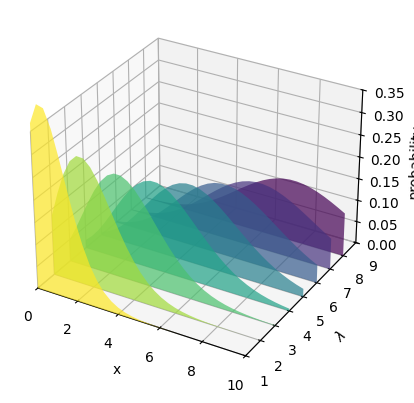

In [22]:
_gamma_v = np.vectorize(gamma)
N = 31
x = np.linspace(0., 10., N)
lambdas = range(1, 9)

ax = plt.figure().add_subplot(projection='3d')

facecolors = plt.colormaps['viridis_r'](np.linspace(0, 1, len(lambdas)))

for i, l in enumerate(lambdas):
    # Note fill_between can take coordinates as length N vectors, or scalars
    ax.fill_between(x, l, l**x * np.exp(-l) / _gamma_v(x + 1),
                    x, l, 0,
                    facecolors=facecolors[i], alpha=.7)

ax.set(xlim=(0, 10), ylim=(1, 9), zlim=(0, 0.35),
       xlabel='x', ylabel=r'$\lambda$', zlabel='probability')

plt.show()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

C:\Program Files\Python313\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1328: RuntimeWarning: divide by zero encountered in divide
  vs = vs / np.linalg.norm(vs, axis=1)[:, np.newaxis]
C:\Program Files\Python313\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1328: RuntimeWarning: invalid value encountered in divide
  vs = vs / np.linalg.norm(vs, axis=1)[:, np.newaxis]
C:\Program Files\Python313\Lib\site-packages\numpy\_core\numeric.py:1753: RuntimeWarning: invalid value encountered in multiply
  multiply(a1, b2, out=cp0)
C:\Program Files\Python313\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1403: RuntimeWarning: divide by zero encountered in divide
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


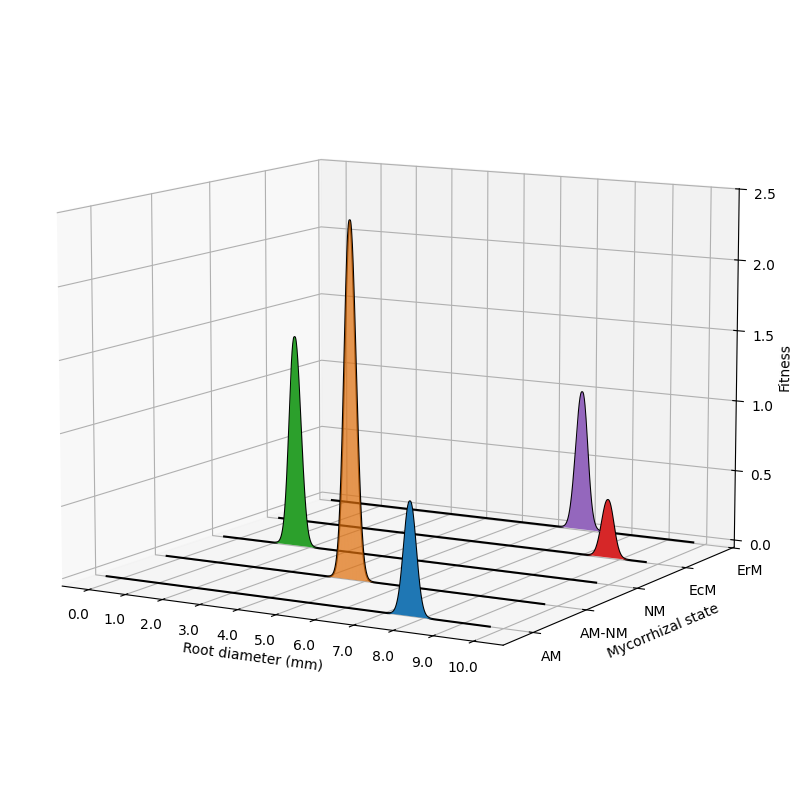

In [23]:
fig, axes = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_size_inches(10, 10)

x_axis_ticks = np.linspace(start=0, stop=10, num=11)
y_axis_ticks = np.linspace(start=1, stop=9, num=5)

_x = np.linspace(start=0, stop=10, num=1000)
x_peak_positions = (8, 5, 2, 9, 7) # ["AM", "AM-NM", "NM", "EcM", "ErM"]

axes.set_xticks(ticks=x_axis_ticks, labels=x_axis_ticks)
axes.set_yticks(ticks=y_axis_ticks, labels=["AM", "AM-NM", "NM", "EcM", "ErM"])

axes.set_xlabel(r"Root diameter (mm)")
axes.set_ylabel(r"Mycorrhizal state")
axes.set_zlabel(r"Fitness")

# https://stackoverflow.com/questions/75275130/z-label-does-not-show-up-in-3d-matplotlib-scatter-plot
# z axis label not showing properly is a padding issue
axes.zaxis.labelpad = 0.5

for xp, y in zip(x_peak_positions, y_axis_ticks - 0.5):
    z_top = norm.pdf(_x, loc=xp, scale=0.15) * np.random.rand() # introduce height variation between peaks without reloacting the peak positions
    axes.fill_between(x1=_x, x2=_x, y1=y, y2=y, z1=0, z2=z_top, alpha=1.) # note fill_between can take coordinates as length N vectors, or scalars
    axes.plot(xs=_x, ys=y, zs=z_top, color="black")

axes.view_init(elev=10, azim=300)
# plt.show()
plt.savefig(fname=r"../plots/fitness3d.png", format=r"png", dpi=500)

In [74]:
np.linspace(start=0.1, stop=.9, num=5)

array([0.1, 0.3, 0.5, 0.7, 0.9])